In [1]:
import numpy as np
import matplotlib.pyplot as plt

# "pip install colossus"
from colossus.halo.concentration import modelDiemer19
from colossus.cosmology import cosmology
from colossus.utils import utilities
from colossus import defaults
defaults.persistence = '' # tell colossus to not cache files
from colossus.lss.mass_function import massFunction

import pickle

from scipy.interpolate import interp1d

You'll need to modify the colossus.cosmology.cosmology file in order to get this to work 

line 600: 

self.R_min_sigma = 1E-40

self.R_max_sigma = 1E4

self.R_Nbins_sigma = 500

self.R_Nbins_sigma_klimits = 500.0

self.accuracy_sigma = 1E-4

In [2]:
class ModifiedPowerSpectrum(object):
    """
    This class makes modified P(k) models, tabulates them, and then uses colossus to compute halo mass functions and concentration mass relations
    """
    def __init__(self, k_pivot=0.05, sigma8=0.82):
        """
        Initialize cosmology and a LambdaCDM power spectrum
        """
        cosmo = cosmology.setCosmology('planck18', persistence = 'r')
        self.kref = 10**np.linspace(-5.0, 3.7, 3000)
        self.k_pivot = k_pivot
        self.Pkref = cosmo.matterPowerSpectrum(self.kref)
        
    def pk_tilted(self, n_s, ar, min_k=None):
        """
        Add a tilt to the power spectrum; if min_k is specified then the tilt only kicks in for k > min_k

        ns: a constant tilt (k/k0)^ns
        ar: a running term (k/k0)^a*log(k/k0)
        """
        running = n_s + ar * np.log(self.kref / self.k_pivot)
        if min_k is None:
            tilt = (self.kref / self.k_pivot) ** running
        else:
            tilt = (self.kref / min_k) ** running
            tilt[np.where(self.kref < min_k)[0]] = 1.0
        return tilt * self.Pkref

    def pk_bump(self, amp, k0, k_sigma_dex):
        """
        Adds a bump parameterized as a Gaussian with amplitude, position, and width in dex
        """
        tilt = 1 + amp*np.exp(-0.5 * (np.log10(self.kref) - np.log10(k0))**2 / k_sigma_dex**2)
        return tilt * self.Pkref

    def pk_cutoff(self, k0):
        """
        A WDM-like cutoff in the matter power spectrum
        """
        nu = 1.12
        tilt = (1 + (self.kref / k0)**nu) ** (-5/nu)
        return tilt * self.Pkref

    def evaluate_concentrations(self, m, z, ns, ar, min_k=None, pk_model='tilt'): 
        """
        Compute concentrations for the model 
        """
        cosmo = cosmology.setCosmology('planck18', persistence = 'r')
        custom_pk = np.empty((len(self.kref), 2))
        custom_pk[:, 0] = np.log10(self.kref)
        if pk_model == 'tilt':
            custom_pk[:, 1] = np.log10(self.pk_tilted(ns, ar, min_k))
        elif pk_model == 'bump':
            custom_pk[:, 1] = np.log10(self.pk_bump(ns, ar, min_k))
        elif pk_model == 'wdm':
            custom_pk[:, 1] = np.log10(self.pk_cutoff(ns))
        file_path = './custom.txt'
        np.savetxt(file_path, X=custom_pk)

        ps_args = dict(model='custom', path=file_path, persistence='r')
        c, _ = modelDiemer19(m, z, ps_args=ps_args)
        return c

    def evaluate_mass_function(self, m, z, ns, ar, min_k=None, pk_model='tilt'): 
        """
        Evaluate the halo mass function for this model
        """
        cosmo = cosmology.setCosmology('planck18', persistence = 'r')
        custom_pk = np.empty((len(self.kref), 2))
        custom_pk[:, 0] = np.log10(self.kref)
        if pk_model == 'tilt':
            custom_pk[:, 1] = np.log10(self.pk_tilted(ns, ar, min_k))
        elif pk_model == 'bump':
            custom_pk[:, 1] = np.log10(self.pk_bump(ns, ar, min_k))
        elif pk_model == 'wdm':
            custom_pk[:, 1] = np.log10(self.pk_cutoff(ns))
        file_path = './custom.txt'
        np.savetxt(file_path, X=custom_pk)

        ps_args = dict(model='custom', path=file_path, persistence='r')
        dndlogm = massFunction(m, z, q_in='M', q_out='dndlnM', ps_args=ps_args)
        return dndlogm

    def evaluate_scaling(self, z, ns, ar, min_k=None, 
                        mlow=10**7, mhigh=10**9, pk_model='tilt'): 
        """
        Evaluate the abundance/concentration relative to CDM at two mass scales mlow and mhigh
        """
        dndlogm_reference = self.evaluate_mass_function(mlow, z, 0.0, 0.0)
        dndlogm = self.evaluate_mass_function(mlow, z, ns, ar, min_k, pk_model=pk_model)
        ratio_mfunc_low = dndlogm / dndlogm_reference

        dndlogm_reference = self.evaluate_mass_function(mhigh, z, 0.0, 0.0)
        dndlogm = self.evaluate_mass_function(mhigh, z, ns, ar, min_k, pk_model=pk_model)
        ratio_mfunc_high = dndlogm / dndlogm_reference

        c_ref = self.evaluate_concentrations(mhigh, z, 0.0, 0.0)
        c = self.evaluate_concentrations(mhigh, z, ns, ar, min_k, pk_model=pk_model)
        ratio_c_high = c / c_ref

        c_ref = self.evaluate_concentrations(mlow, z, 0.0, 0.0)
        c = self.evaluate_concentrations(mlow, z, ns, ar, min_k, pk_model=pk_model)
        ratio_c_low = c / c_ref

        return ratio_mfunc_low, ratio_mfunc_high, ratio_c_low, ratio_c_high
        

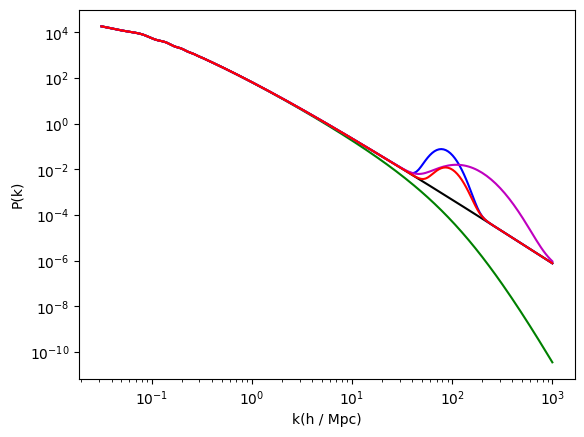

In [9]:
cosmo = cosmology.setCosmology('planck18', persistence = 'r')
k = 10**np.linspace(-1.5, 3.0, 200)

power_spectrum = ModifiedPowerSpectrum()

reference_power_spectrum = np.empty((len(power_spectrum.kref), 2))
reference_power_spectrum[:, 0] = np.log10(power_spectrum.kref)
amp = 0.0
k0 = 0.0
k_sigma_dex = 0.5
reference_power_spectrum[:, 1] = np.log10(power_spectrum.pk_tilted(0.0, 0.0))
file_path = './reference.txt'
np.savetxt(file_path, X=reference_power_spectrum)
ps_args_reference = dict(model = 'reference_model', path = file_path, persistence='r')
pk_reference = cosmo.matterPowerSpectrum(k, **ps_args_reference)

custom_pk = np.empty((len(power_spectrum.kref), 2))
custom_pk[:, 0] = np.log10(power_spectrum.kref)
k_cut = 150
custom_pk[:, 1] = np.log10(power_spectrum.pk_cutoff(k_cut))
file_path = './custom.txt'
np.savetxt(file_path, X=custom_pk)
ps_args = dict(model = 'custom_model1', path = file_path, persistence='r')
pk_custom1 = cosmo.matterPowerSpectrum(k, **ps_args)

custom_pk = np.empty((len(power_spectrum.kref), 2))
custom_pk[:, 0] = np.log10(power_spectrum.kref)
amp = 100
k0 = 90
bump_width_dex = 0.1
custom_pk[:, 1] = np.log10(power_spectrum.pk_bump(amp, k0, bump_width_dex))
file_path = './custom.txt'
np.savetxt(file_path, X=custom_pk)
ps_args = dict(model = 'custom_model2', path = file_path, persistence='r')
pk_custom2 = cosmo.matterPowerSpectrum(k, **ps_args)

custom_pk = np.empty((len(power_spectrum.kref), 2))
custom_pk[:, 0] = np.log10(power_spectrum.kref)
amp = 100
k0 = 200
bump_width_dex = 0.2
custom_pk[:, 1] = np.log10(power_spectrum.pk_bump(amp, k0, bump_width_dex))
file_path = './custom.txt'
np.savetxt(file_path, X=custom_pk)
ps_args = dict(model = 'custom_model3', path = file_path, persistence='r')
pk_custom3 = cosmo.matterPowerSpectrum(k, **ps_args)

custom_pk = np.empty((len(power_spectrum.kref), 2))
custom_pk[:, 0] = np.log10(power_spectrum.kref)
amp = 20
k0 = 100
bump_width_dex = 0.1
custom_pk[:, 1] = np.log10(power_spectrum.pk_bump(amp, k0, bump_width_dex))
file_path = './custom.txt'
np.savetxt(file_path, X=custom_pk)
ps_args = dict(model = 'custom_model4', path = file_path, persistence='r')
pk_custom4 = cosmo.matterPowerSpectrum(k, **ps_args)

plt.figure()
plt.loglog()
plt.xlabel('k(h / Mpc)')
plt.ylabel('P(k)')
plt.plot(k, pk_reference, '-', color='k')
plt.plot(k, pk_custom1, '-', color='g')
plt.plot(k, pk_custom2, '-', color='b')
plt.plot(k, pk_custom3, '-', color='m')
plt.plot(k, pk_custom4, '-', color='r')
#plt.savefig('pk_tilted.pdf', bbox_inches='tight')

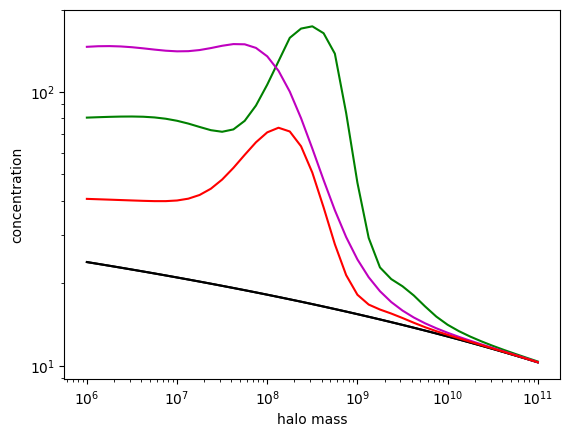

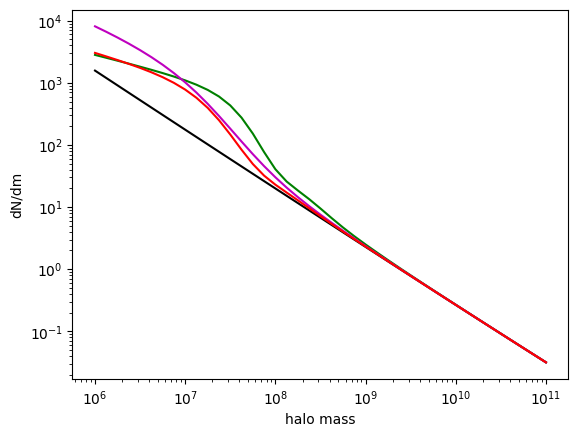

In [10]:
m = np.logspace(6., 11, 41)

# these parameters should be the same as the ones used to create the models in the previous cell
z = 0
ns = 0.0
ar = 0.0
min_k = None
cref = power_spectrum.evaluate_concentrations(m, z, ns, ar)
dndm_ref = power_spectrum.evaluate_mass_function(m, z, ns, ar, min_k=min_k, pk_model='tilt')
plt.plot(m, cref, color='k')

# z = 0
# ns = 0.0
# ar = 0.1
# min_k = 10
# c1 = power_spectrum.evaluate_concentrations(m, z, ns, ar, min_k)
# dndm_1 = power_spectrum.evaluate_mass_function(m, z, ns, ar, min_k=min_k, pk_model='tilt')

z=0
amp = 100
k0 = 90
bump_width_dex = 0.1
c2 = power_spectrum.evaluate_concentrations(m, z, amp, k0, bump_width_dex, pk_model='bump')
dndm_2 = power_spectrum.evaluate_mass_function(m, z, amp, k0, bump_width_dex, pk_model='bump')

z=0
amp = 100
k0 = 200
bump_width_dex = 0.2
c3 = power_spectrum.evaluate_concentrations(m, z, amp, k0, bump_width_dex, pk_model='bump')
dndm_3 = power_spectrum.evaluate_mass_function(m, z, amp, k0, bump_width_dex, pk_model='bump')

z=0
amp = 20
k0 = 100
bump_width_dex = 0.1
c4 = power_spectrum.evaluate_concentrations(m, z, amp, k0, bump_width_dex, pk_model='bump')
dndm_4 = power_spectrum.evaluate_mass_function(m, z, amp, k0, bump_width_dex, pk_model='bump')

plt.plot(m, cref, color='k')
#plt.plot(m, c1, color='b')
plt.plot(m, c2, color='g')
plt.plot(m, c3, color='m')
plt.plot(m, c4, color='r')
plt.xlabel('halo mass')
plt.ylabel('concentration')
plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
plt.show() 

plt.plot(m, dndm_ref, color='k')
#plt.plot(m, dndm_1, color='b')
plt.plot(m, dndm_2, color='g')
plt.plot(m, dndm_3, color='m')
plt.plot(m, dndm_4, color='r')
plt.xlabel('halo mass')
plt.ylabel('dN/dm')
plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
plt.show() 


rhalf = 40 * (rvir / 10) ** 1.0

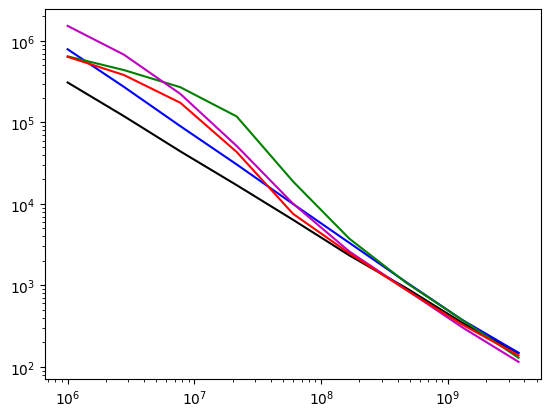

In [16]:
def sample_from_mass_function(num_draw, m, dndm_model):
    
    cdf = []
    for i in range(0, len(dndm_model)):
        cdf.append(np.sum(dndm_model[0:i]))
    cdf =  np.array(cdf) / cdf[-1]
    cdf_inverse = interp1d(cdf, np.log10(m))    
    u = np.random.uniform(0, 1, num_draw)
    m_samples = 10**cdf_inverse(u)
    return m_samples

def sample_mc_relation(m_eval, m, mc_model):

    mc_relation_interp = interp1d(np.log10(m), mc_model)
    return mc_relation_interp(np.log10(m_eval))

num_draw_ref = 500000
m_samples = sample_from_mass_function(num_draw_ref, m, dndm_ref)
h, b = np.histogram(m_samples, bins=np.logspace(6,10,10))
plt.loglog(b[0:-1], h, color='k')

scale_1 = 2.4
num_draw_1 = int(scale_1 * num_draw_ref)
m_samples = sample_from_mass_function(num_draw_1, m, dndm_1)
h, b = np.histogram(m_samples, bins=np.logspace(6,10,10))
plt.loglog(b[0:-1], h, color='b')

scale_2 = 3.
num_draw_2 = int(scale_2 * num_draw_ref)
m_samples = sample_from_mass_function(num_draw_2, m, dndm_2)
h, b = np.histogram(m_samples, bins=np.logspace(6,10,10))
plt.loglog(b[0:-1], h, color='g')

scale_3 = 5
num_draw_3 = int(scale_3 * num_draw_ref)
m_samples = sample_from_mass_function(num_draw_3, m, dndm_3)
h, b = np.histogram(m_samples, bins=np.logspace(6,10,10))
plt.loglog(b[0:-1], h, color='m')

scale_4 = 2.5
num_draw_4 = int(scale_4 * num_draw_ref)
m_samples = sample_from_mass_function(num_draw_4, m, dndm_4)
h, b = np.histogram(m_samples, bins=np.logspace(6,10,10))
plt.loglog(b[0:-1], h, color='r')


rhalf = 40 * (rvir / 10) ** 1.0

In [17]:
# num_draw_ref = 200000
# m_samples = sample_from_mass_function(num_draw_ref, m, dndm_ref)
# c_cdm = sample_mc_relation(m_samples, m, cref)

# c_medians_cdm = []
# for i in range(0, len(m)-1):
#     inds = np.where(np.logical_and(m_samples>=m[i], m_samples<m[i+1]))[0]
#     c_medians_cdm.append(np.median(c_cdm[inds]))

# m_samples = sample_from_mass_function(num_draw_ref, m, dndm_1)
# c_1_samples = sample_mc_relation(m_samples, m, c1)
# c_medians_1 = []
# for i in range(0, len(m)-1):
#     inds = np.where(np.logical_and(m_samples>=m[i], m_samples<m[i+1]))[0]
#     c_medians_1.append(np.median(c_1_samples[inds]))

# m_samples = sample_from_mass_function(num_draw_ref, m, dndm_2)
# c_2_samples = sample_mc_relation(m_samples, m, c2)
# c_medians_2 = []
# for i in range(0, len(m)-1):
#     inds = np.where(np.logical_and(m_samples>=m[i], m_samples<m[i+1]))[0]
#     c_medians_2.append(np.median(c_2_samples[inds]))

# plt.plot(m[0:-1], c_medians_cdm, color='k')
# plt.plot(m[0:-1], c_medians_1, color='b')
# plt.plot(m[0:-1], c_medians_2, color='g')
# plt.gca().set_xscale('log')
# plt.gca().set_yscale('log')

In [54]:
from pyHalo.Halos.lens_cosmo import LensCosmo 

lc = LensCosmo()

def rvir_from_mass(m):
    rho_crit = 136 # solar masses / kpc^3
    return (3*m / (4*np.pi*rho_crit))**(1/3)
    
def rhalf_from_mass(m):
    rvir = rvir_from_mass(m)
    return 40 * (rvir / 10)

def menclosed_from_m(m, m_model, cm_model): 

    z = 0
    c = sample_mc_relation(m, m_model, cm_model)
    c = np.exp(np.log(c) + np.random.normal(0, 0.15))
    rhos, rs, r200 = lc.NFW_params_physical(m, c, z)
    rhalf = np.exp(np.log(0.04 * (r200 / 10)) + np.random.normal(0, 0.6)) # in kpc
    # integrate profile to rhalf
    X = rhalf/rs
    fc = np.log(1+X) - X/(1+X)
    m_enclosed = 4*np.pi*rhos*rs**3 * fc
    return rhalf, m_enclosed

def generate_samples(N, m_tabulated, dndm_tabulated, cm_tabulated, m_min=10**8, r_half_min=0.01,
                    m_half_mode=None):

    z = 0
    rhalf = np.empty(N)
    menc = np.empty(N)
    m_samples = sample_from_mass_function(N, m_tabulated, dndm_tabulated)
    inds = np.where(m_samples >= m_min)[0]
    m_samples = m_samples[inds]
    c = sample_mc_relation(m_samples, m_tabulated, cm_tabulated)

    if m_half_mode is not None:
        c *= (1 + 60 * m_half_mode / m_samples) ** -0.17
    
    c_samples = np.exp(np.log(c) + np.random.normal(0, 0.15, size=len(c))) # add scatter
    rhos, rs, r200 = lc.NFW_params_physical(m_samples, c_samples, z)
    rhalf = np.exp(np.log(0.04 * (r200 / 10)) + np.random.normal(0, 0.6, size=len(r200))) # in kpc
    inds = np.where(rhalf > r_half_min)[0]
    X = rhalf/rs
    fc = np.log(1+X) - X/(1+X)
    m_enclosed = 4*np.pi*rhos*rs**3 * fc
    return rhalf[inds], m_enclosed[inds], m_samples[inds], c_samples[inds]

def cumulative_mass_function(m_model, m_min=2, m_max=10, num_bins=10, normed=True): 
    
    masses = np.logspace(m_min, m_max, num_bins)
    h, b = np.histogram(m_model, bins=masses)
    m_cumulative = []
    for i in range(0, len(h)):
        m_cumulative.append(np.sum(h[0:i]))
    m_cumulative = np.array(m_cumulative)  
    print(normed)
    if normed:
        m_cumulative = 1 - m_cumulative/m_cumulative[-1] 
    else:
        m_cumulative = m_cumulative[-1]  - m_cumulative
    return masses[0:-1], np.array(m_cumulative)

300


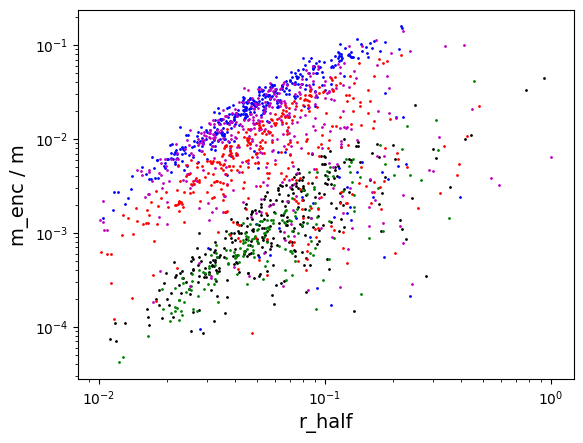

In [72]:
m = np.logspace(6., 11, 41)
N_cdm = 25000
rhalf_cdm, menc_cdm, m_samples_cdm, c_samples_cdm = generate_samples(N_cdm, m, dndm_ref, cref)
rhalfwdm, mencwdm, m_sampleswdm, c_sampleswdm = generate_samples(int(N_cdm), m, dndm_1, cref,
                                                                m_half_mode=10**7.0)
rhalfbump1, mencbump1, m_samplesbump1, c_samplesbump1 = generate_samples(int(N_cdm*scale_1), m, dndm_2, c2)
rhalfbump2, mencbump2, m_samplesbump2, c_samplesbump2 = generate_samples(int(N_cdm*scale_3), m, dndm_3, c3)
rhalfbump3, mencbump3, m_samplesbump3, c_samplesbump3 = generate_samples(int(N_cdm*scale_4), m, dndm_4, c4)
print(len(rhalf_cdm))
fig = plt.figure()
ax = plt.subplot(111)

ax.scatter(rhalf_cdm, menc_cdm/m_samples_cdm, color='k',s=1)
ax.scatter(rhalfbump1, mencbump1/m_samplesbump1, color='b', s=1)
ax.scatter(rhalfwdm, mencwdm/m_sampleswdm, color='g', s=1)
ax.scatter(rhalfbump2, mencbump2/m_samplesbump2, color='m', s=1)
ax.scatter(rhalfbump3, mencbump3/m_samplesbump3, color='r', s=1)

ax.set_xlabel('r_half', fontsize=14)
ax.set_ylabel('m_enc / m', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')

(array([0.14851655, 0.34653862, 0.49505518, 0.64357173, 0.51155702,
        0.41254598, 0.19802207, 0.14851655, 0.09901104, 0.01650184]),
 array([4.04846823, 4.37961198, 4.71075572, 5.04189947, 5.37304322,
        5.70418696, 6.03533071, 6.36647446, 6.6976182 , 7.02876195,
        7.3599057 ]),
 <BarContainer object of 10 artists>)

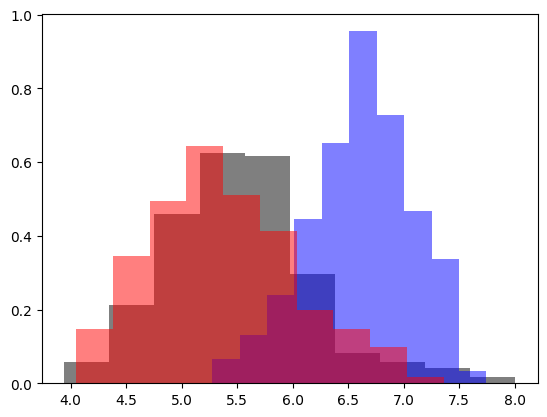

In [73]:
plt.hist(np.log10(menc_cdm),color='k',alpha=0.5,density=True)
plt.hist(np.log10(mencbump1), color='b', alpha=0.5,density=True)
plt.hist(np.log10(mencwdm), color='r',alpha=0.5,density=True)

False
False
False
False
False


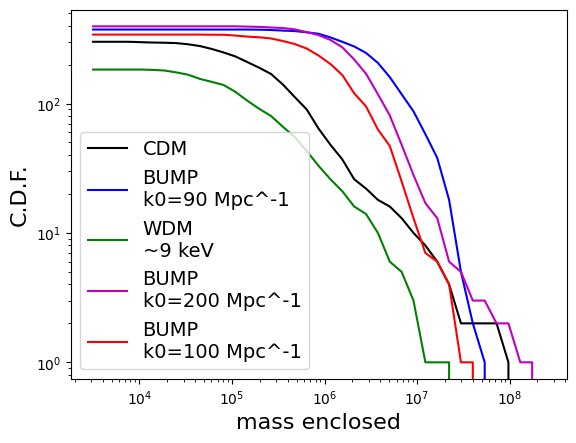

In [74]:
num_bins = 40
log10m_min = 3.5
log10m_max = 8.5
normed = False
mplot, m_cumulative_cdm = cumulative_mass_function(menc_cdm, m_min=log10m_min, m_max=log10m_max, 
                                                  num_bins=num_bins, normed=normed)
_, m_cumulative_1 = cumulative_mass_function(mencbump1, m_min=log10m_min, m_max=log10m_max, 
                                                  num_bins=num_bins, normed=normed)
_, m_cumulative_2 = cumulative_mass_function(mencwdm, m_min=log10m_min, m_max=log10m_max, 
                                                  num_bins=num_bins, normed=normed)
_, m_cumulative_3 = cumulative_mass_function(mencbump2, m_min=log10m_min, m_max=log10m_max, 
                                                  num_bins=num_bins, normed=normed)
_, m_cumulative_4 = cumulative_mass_function(mencbump3, m_min=log10m_min, m_max=log10m_max, 
                                                  num_bins=num_bins, normed=normed)

fig = plt.figure()
ax = plt.subplot(111)

ax.plot(mplot, m_cumulative_cdm, color='k', label='CDM')
ax.plot(mplot, m_cumulative_1, color='b', label='BUMP\nk0=90 Mpc^-1')
ax.plot(mplot, m_cumulative_2, color='g', label='WDM\n~9 keV')
ax.plot(mplot, m_cumulative_3, color='m', label='BUMP\nk0=200 Mpc^-1')
ax.plot(mplot, m_cumulative_4, color='r', label='BUMP\nk0=100 Mpc^-1')

ax.legend(fontsize=14)

ax.set_xlabel('mass enclosed', fontsize=16)
ax.set_ylabel('C.D.F.', fontsize=16)

ax.set_xscale('log')
ax.set_yscale('log')

In [71]:
cdm_data = np.empty((len(rhalf_cdm), 4))
cdm_data[:,0], cdm_data[:,1], cdm_data[:,2], cdm_data[:,3] = rhalf_cdm, menc_cdm, m_samples_cdm, c_samples_cdm

bump1_data = np.empty((len(rhalfbump1), 4))
bump1_data[:,0], bump1_data[:,1], bump1_data[:,2], bump1_data[:,3] = rhalfbump1, mencbump1, m_samplesbump1, c_samplesbump1

bump2_data = np.empty((len(rhalfbump2), 4))
bump2_data[:,0], bump2_data[:,1], bump2_data[:,2], bump2_data[:,3] = rhalfbump2, mencbump2, m_samplesbump2, c_samplesbump2

bump3_data = np.empty((len(rhalfbump3), 4))
bump3_data[:,0], bump3_data[:,1], bump3_data[:,2], bump3_data[:,3] = rhalfbump3, mencbump3, m_samplesbump3, c_samplesbump3

bump3_data = np.empty((len(rhalfbump3), 4))
bump3_data[:,0], bump3_data[:,1], bump3_data[:,2], bump3_data[:,3] = rhalfbump3, mencbump3, m_samplesbump3, c_samplesbump3

wdm_data = np.empty((len(rhalfwdm), 4))
wdm_data[:,0], wdm_data[:,1], wdm_data[:,2], wdm_data[:,3] = rhalfwdm, mencwdm, m_sampleswdm, c_sampleswdm

column_headers = "r_half [kpc], M_enc(r_half) [M_sun], M_200 [M_sun], concentration"
np.savetxt('cdm_data.txt', X=cdm_data, header=column_headers,fmt='%.5f', delimiter=',',)
np.savetxt('bump1_data.txt', X=bump1_data, header=column_headers,fmt='%.5f', delimiter=',',)
np.savetxt('bump2_data.txt', X=bump2_data, header=column_headers,fmt='%.5f', delimiter=',',)
np.savetxt('bump3_data.txt', X=bump3_data, header=column_headers,fmt='%.5f', delimiter=',',)
np.savetxt('wdm7_data.txt', X=wdm7_data, header=column_headers,fmt='%.5f', delimiter=',',)

# cdm_data = np.column_stack((mplot, m_cumulative_cdm))
# bump1_data = np.column_stack((mplot, m_cumulative_1))
# bump2_data = np.column_stack((mplot, m_cumulative_3))
# bump3_data = np.column_stack((mplot, m_cumulative_4))
# wdm7_data = np.column_stack((mplot, m_cumulative_2))

# column_headers = "mass enclosed, CDF"
# np.savetxt('cdm_data.txt', X=cdm_data, header=column_headers,fmt='%.5f', delimiter=',',)
# np.savetxt('bump1_data.txt', X=bump1_data, header=column_headers,fmt='%.5f', delimiter=',',)
# np.savetxt('bump2_data.txt', X=bump2_data, header=column_headers,fmt='%.5f', delimiter=',',)
# np.savetxt('bump3_data.txt', X=bump3_data, header=column_headers,fmt='%.5f', delimiter=',',)
# np.savetxt('wdm7_data.txt', X=wdm7_data, header=column_headers,fmt='%.5f', delimiter=',',)